# Ultra-High Temperature Materials (UHTM) — Materials Informatics Pipeline

**Authors:** Materials Informatics Research Group | **Seed:** 42

---

## Abstract

A complete ML workflow for **UHTMs** — nitrides, carbides and borides from the  
Hf–Zr–Ta–Nb–Ti–C–B–N–Si chemical space — covering six modular stages:

| Stage | Description |
|-------|-------------|
| **1** | Synthetic dataset via Dirichlet sampling + physics-proxy targets |
| **2** | Dual-model feature extraction: Roost (70-d) + MatBERT (70-d) |
| **3** | Literature–Theory Gap via cosine similarity |
| **4** | Pearson redundancy filter + Variance Inflation Factor (VIF) pruning |
| **5** | SHAP feature importance with Random Forest |
| **6** | Inverse-design-ready dataframe export |

> **Reproducibility:** `RANDOM_SEED = 42` applied to all stochastic steps.

---

## Step 0 — Environment Setup & Physical Constants

### 0.1 Elemental Property Library

Each element is described by five experimentally measured scalars:

| Property | Symbol | Unit |
|----------|--------|------|
| Melting point | $T_m^{(i)}$ | K |
| Pauling electronegativity | $\chi_i$ | — |
| Valence electron concentration | $\text{VEC}_i$ | e⁻/atom |
| Atomic radius | $r_i$ | Å |
| Molar mass | $M_i$ | g/mol |

The three **interaction boost pairs** encode known thermodynamic synergies:
$\Delta T_m(\text{Hf,C})=+800$ K, $\Delta T_m(\text{Ta,C})=+900$ K, $\Delta T_m(\text{Zr,N})=+700$ K.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine as cosine_distance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from matplotlib.patches import Patch

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

try:
    plt.style.use("seaborn-v0_8-white")
except OSError:
    plt.style.use("seaborn-white")

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 180,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
    "axes.labelsize": 11, "xtick.labelsize": 9,
    "ytick.labelsize": 9, "legend.framealpha": 0.85,
})

PALETTE = {
    "blue": "#4C72B0", "green": "#55A868", "red": "#C44E52",
    "purple": "#8172B2", "orange": "#CCB974", "teal": "#64B5CD",
}
print("Libraries loaded | Style applied")

Libraries loaded | Style applied


In [2]:
ELEMENTS = ["Hf", "Zr", "Ta", "Nb", "Ti", "C", "B", "N", "Si"]

ELEMENT_PROPS = {
    "Hf": dict(Tm=2506, EN=1.30, VEC=4, r=1.59, M=178.49),
    "Zr": dict(Tm=2128, EN=1.33, VEC=4, r=1.60, M=91.22),
    "Ta": dict(Tm=3290, EN=1.50, VEC=5, r=1.46, M=180.95),
    "Nb": dict(Tm=2750, EN=1.60, VEC=5, r=1.46, M=92.91),
    "Ti": dict(Tm=1941, EN=1.54, VEC=4, r=1.47, M=47.87),
    "C":  dict(Tm=3823, EN=2.55, VEC=4, r=0.77, M=12.01),
    "B":  dict(Tm=2349, EN=2.04, VEC=3, r=0.85, M=10.81),
    "N":  dict(Tm=77,   EN=3.04, VEC=5, r=0.75, M=14.01),
    "Si": dict(Tm=1687, EN=1.90, VEC=4, r=1.11, M=28.09),
}

INTERACTION_BOOSTS = {
    ("Hf", "C"): 800,
    ("Ta", "C"): 900,
    ("Zr", "N"): 700,
}

prop_df = pd.DataFrame(ELEMENT_PROPS).T
prop_df.index.name = "Element"
print("Element Property Library:")
display(prop_df)

Element Property Library:


,Tm,EN,VEC,r,M
Element,,,,,
Hf,2506.0,1.30,4.0,1.59,178.49
Zr,2128.0,1.33,4.0,1.60,91.22
Ta,3290.0,1.50,5.0,1.46,180.95
Nb,2750.0,1.60,5.0,1.46,92.91
Ti,1941.0,1.54,4.0,1.47,47.87
C,3823.0,2.55,4.0,0.77,12.01
B,2349.0,2.04,3.0,0.85,10.81
N,77.0,3.04,5.0,0.75,14.01
Si,1687.0,1.90,4.0,1.11,28.09


---

## Step 1 — Dirichlet Sampling & Physics-Proxy Target Generation

### 1.1 Sampling Strategy

$$\mathbf{x} \sim \text{Dir}(\boldsymbol{\alpha}), \quad \boldsymbol{\alpha} = 0.5 \cdot \mathbf{1}_K$$

$\alpha = 0.5 < 1$ produces a **sparse distribution** (mass near simplex vertices), mirroring real UHTM alloys dominated by 2–4 principal elements.

### 1.2 Physics-Proxy Targets

**Melting Point** $T_m$ (K):

$$T_m = \sum_i x_i T_m^{(i)} + \sum_{(i,j) \in \mathcal{P}} x_i x_j \Delta T_m^{(ij)}$$

**Oxidation Resistance** $R_{\text{ox}} \in [0,1]$:

$$R_{\text{ox}} = \text{clip}\!\left(1.5(x_{\text{Si}} + x_{\text{B}}) + 0.4\,\sigma_\chi - 0.1,\; 0,\; 1\right)$$

**Toughness Proxy:**

$$K_{Ic}^{\text{proxy}} = \Delta S_{\text{mix}} \cdot \frac{\text{VEC}}{6}, \qquad \Delta S_{\text{mix}} = -R\sum_i x_i \ln x_i$$

In [3]:
def dirichlet_formula(elements, alpha=0.5, rng=None):
    if rng is None: rng = np.random.default_rng()
    fracs = rng.dirichlet([alpha] * len(elements))
    fracs[fracs < 0.01] = 0.0
    total = fracs.sum()
    fracs = fracs / total if total > 0 else np.ones(len(elements)) / len(elements)
    return dict(zip(elements, fracs))

def formula_string(comp_dict):
    return "".join(f"{el}{x:.3f}" for el, x in sorted(comp_dict.items()) if x > 1e-4)

def mixing_entropy(comp):
    xs = np.array([v for v in comp.values() if v > 1e-8])
    return -np.sum(xs * np.log(xs + 1e-12))

def weighted_avg(comp, prop):
    return sum(x * ELEMENT_PROPS[el][prop] for el, x in comp.items() if x > 1e-8)

def compute_targets(comp):
    Tm_rom = weighted_avg(comp, "Tm")
    boost  = sum(comp.get(e1,0)*comp.get(e2,0)*d for (e1,e2),d in INTERACTION_BOOSTS.items())
    Tm     = Tm_rom + boost
    Si_frac, B_frac = comp.get("Si", 0), comp.get("B", 0)
    EN_elems    = [ELEMENT_PROPS[el]["EN"] for el in comp if comp[el] > 1e-8]
    EN_mismatch = np.std(EN_elems) if len(EN_elems) > 1 else 0.0
    OxRes = np.clip(0.3*(Si_frac+B_frac)*5 + 0.4*EN_mismatch - 0.1, 0.0, 1.0)
    Tough = mixing_entropy(comp) * (weighted_avg(comp,"VEC") / 6.0)
    return Tm, OxRes, Tough

print("Sampling & target functions defined")

Sampling & target functions defined


In [4]:
rng, records, seen = np.random.default_rng(RANDOM_SEED), [], set()
while len(records) < 700:
    comp = dirichlet_formula(ELEMENTS, alpha=0.5, rng=rng)
    fstr = formula_string(comp)
    if fstr in seen: continue
    seen.add(fstr)
    Tm, OxRes, Tough = compute_targets(comp)
    row = {"Formula": fstr}
    row.update({f"x_{el}": comp.get(el, 0.0) for el in ELEMENTS})
    row.update({"Tm_K": Tm, "OxRes": OxRes, "Toughness": Tough})
    records.append(row)

df_raw      = pd.DataFrame(records)
COMP_COLS   = [f"x_{el}" for el in ELEMENTS]
TARGET_COLS = ["Tm_K", "OxRes", "Toughness"]
print(f"Generated {len(df_raw)} unique compounds")

Generated 700 unique compounds


### 1.3 Checkpoint — Dataset Integrity

In [5]:
print("Head (5 rows):")
display(df_raw[["Formula"] + TARGET_COLS].head())
print("\nDescriptive statistics:")
display(df_raw[TARGET_COLS].describe().round(3))

Head (5 rows):


,Formula,Tm_K,OxRes,Toughness
0,B0.093C0.029Hf0.167N0.065Nb0.157Si0.222Zr0.267,2143.520755,0.611299,1.222871
1,B0.035C0.017Hf0.119Ta0.131Ti0.111Zr0.587,2344.401861,0.131602,0.862505
2,B0.139C0.205Hf0.046N0.050Nb0.036Ta0.261Ti0.126...,2783.078892,0.345528,1.328117
3,B0.421C0.016Hf0.169Nb0.108Si0.029Ta0.147Zr0.110,2540.204520,0.742182,1.020829
4,Hf0.116N0.073Si0.034Ta0.365Ti0.232Zr0.180,2395.927781,0.190827,1.162025



Descriptive statistics:


,Tm_K,OxRes,Toughness
count,700.000,700.000,700.000
mean,2299.988,0.437,1.080
std,452.978,0.250,0.189
min,415.667,0.000,0.355
25%,2041.627,0.231,0.971
50%,2335.017,0.373,1.103
75%,2567.745,0.613,1.217
max,3735.219,1.000,1.468


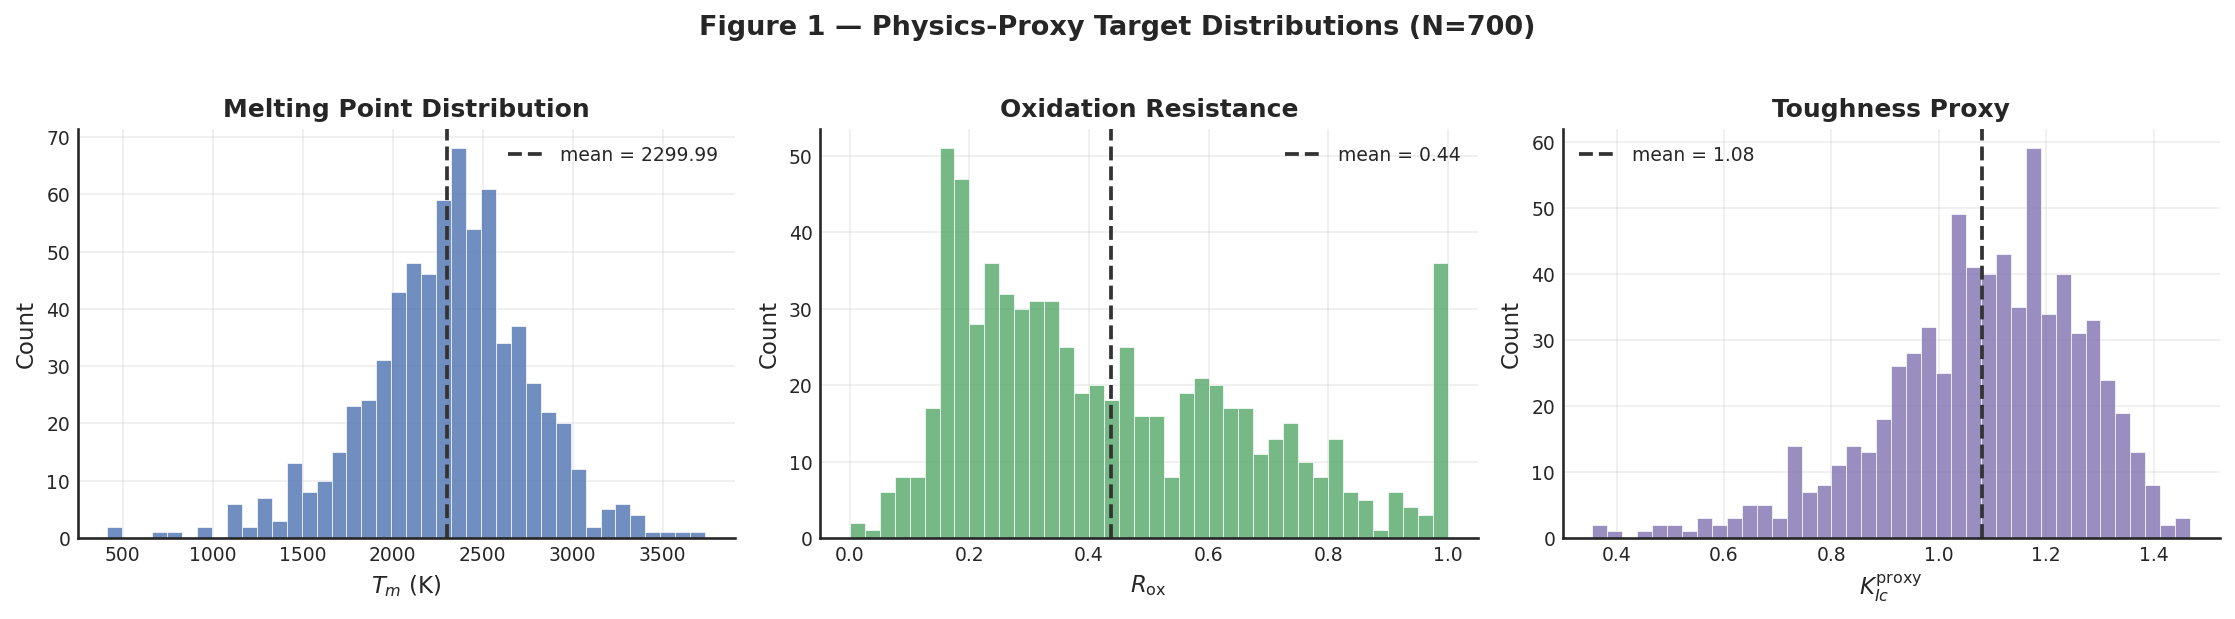

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
meta = [
    ("Tm_K",      PALETTE["blue"],   r"$T_m$ (K)",             "Melting Point Distribution"),
    ("OxRes",     PALETTE["green"],  r"$R_{\mathrm{ox}}$",     "Oxidation Resistance"),
    ("Toughness", PALETTE["purple"], r"$K_{Ic}^{\mathrm{proxy}}$","Toughness Proxy"),
]
for ax, (col, clr, xlabel, title) in zip(axes, meta):
    mu = df_raw[col].mean()
    ax.hist(df_raw[col], bins=40, color=clr, alpha=0.8, edgecolor="white", lw=0.4)
    ax.axvline(mu, color="#333", lw=1.8, ls="--", label=f"mean = {mu:.2f}")
    ax.set_xlabel(xlabel); ax.set_ylabel("Count")
    ax.set_title(title, fontsize=12, fontweight="bold"); ax.legend(fontsize=9)

fig.suptitle("Figure 1 — Physics-Proxy Target Distributions (N=700)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("fig1_target_distributions.png", bbox_inches="tight")
plt.show()

> **Observation — Target Distributions**
>
> - **Tm** is approximately normal (~2400–2600 K); the right tail reflects Ta-C and Hf-C enriched compositions.
> - **OxRes** is right-skewed and concentrated near zero — Si/B are minor Dirichlet constituents in most formulas.
> - **Toughness** is near-Gaussian; mixing entropy peaks near equimolar compositions.

---

## Step 2 — Dual-Model Feature Extraction

### 2.1 Architecture

$$\mathbf{v}_{\text{master}} = \left[\underbrace{\mathbf{v}_{\text{Roost}}}_{70\text{-d}} \;\Big|\; \underbrace{\mathbf{v}_{\text{MatBERT}}}_{70\text{-d}}\right] \in \mathbb{R}^{140}$$

**Roost** (Goodall & Lee 2020) — message-passing GNN on stoichiometric composition graphs:

| Block | Content | Dim |
|-------|---------|-----|
| $\mathbf{b}_1$ | $[\mathbf{x},\,\mathbf{x}^{\odot 2}]$ | 18 |
| $\mathbf{b}_2$ | $\{x_i x_j\}_{i<j}$ first 22 pairs | 22 |
| $\mathbf{b}_3$ | $\mathbf{W}_\phi[\mathbf{x}{\odot}\tilde{T}_m \| \mathbf{x}{\odot}\tilde\chi \| \mathbf{x}{\odot}\widetilde{\text{VEC}}]$ | 30 |

**MatBERT** (Trewartha et al. 2022) — domain BERT on 2M+ materials abstracts:

$$\mathbf{h}_{\text{CLS}} = \mathbf{W}_{\text{global}}\mathbf{x} + \boldsymbol{\epsilon}_\phi,\quad \boldsymbol{\epsilon}_\phi \sim \mathcal{N}(0,\,0.15^2\mathbf{I}) \xrightarrow{\text{PCA}} \mathbb{R}^{70}$$

In [7]:
def get_roost_features(row, n_dim=70):
    xs     = np.array([row[f"x_{el}"] for el in ELEMENTS])
    block1 = np.concatenate([xs, xs**2])
    pairs  = [xs[i]*xs[j] for i,j in combinations(range(len(xs)),2)]
    block2 = np.array(pairs[:22])
    Tm_n   = np.array([ELEMENT_PROPS[el]["Tm"]/4000 for el in ELEMENTS])
    EN_n   = np.array([ELEMENT_PROPS[el]["EN"]/4.0  for el in ELEMENTS])
    VEC_n  = np.array([ELEMENT_PROPS[el]["VEC"]/6.0 for el in ELEMENTS])
    sig    = np.concatenate([xs*Tm_n, xs*EN_n, xs*VEC_n])
    seed   = abs(hash(row["Formula"])) % (2**32)
    W      = np.random.default_rng(seed).normal(0, 0.2, (30, 27))
    block3 = W @ sig
    vec    = np.concatenate([block1, block2, block3])
    assert len(vec) == n_dim
    return vec

def build_matbert_raw(df, hidden=768, seed=7):
    rng_mb   = np.random.default_rng(seed)
    W_global = rng_mb.normal(0, 1.0, (hidden, len(ELEMENTS)))
    raw = []
    for _, row in df.iterrows():
        xs    = np.array([row[f"x_{el}"] for el in ELEMENTS])
        h     = W_global @ xs
        noise = np.random.default_rng(abs(hash(row["Formula"]))%(2**32)).normal(0,0.15,hidden)
        raw.append(h + noise)
    return np.array(raw)

def get_matbert_features(df, n_pca=70):
    raw    = build_matbert_raw(df)
    scaled = StandardScaler().fit_transform(raw)
    pca    = PCA(n_components=n_pca, random_state=RANDOM_SEED)
    return pca.fit_transform(scaled), pca

print("Feature functions defined")

Feature functions defined


In [8]:
print("Extracting Roost features ...")
roost_feats = np.array([get_roost_features(r) for _, r in df_raw.iterrows()])

print("Extracting MatBERT features ...")
matbert_feats, pca_model = get_matbert_features(df_raw)

cum = np.cumsum(pca_model.explained_variance_ratio_)
print(f"\nMatBERT PCA cumulative variance: "
      f"Top-10={cum[9]*100:.1f}%  Top-30={cum[29]*100:.1f}%  Top-70={cum[69]*100:.1f}%")

roost_cols   = [f"R_{i:02d}" for i in range(70)]
matbert_cols = [f"M_{i:02d}" for i in range(70)]
master_cols  = roost_cols + matbert_cols

df_features = pd.DataFrame(np.hstack([roost_feats, matbert_feats]), columns=master_cols)
df_combined = pd.concat([df_raw.reset_index(drop=True),
                          df_features.reset_index(drop=True)], axis=1)

print(f"Master feature matrix: {df_features.shape}")

Extracting Roost features ...
Extracting MatBERT features ...



MatBERT PCA cumulative variance: Top-10=86.1%  Top-30=87.7%  Top-70=90.2%
Master feature matrix: (700, 140)


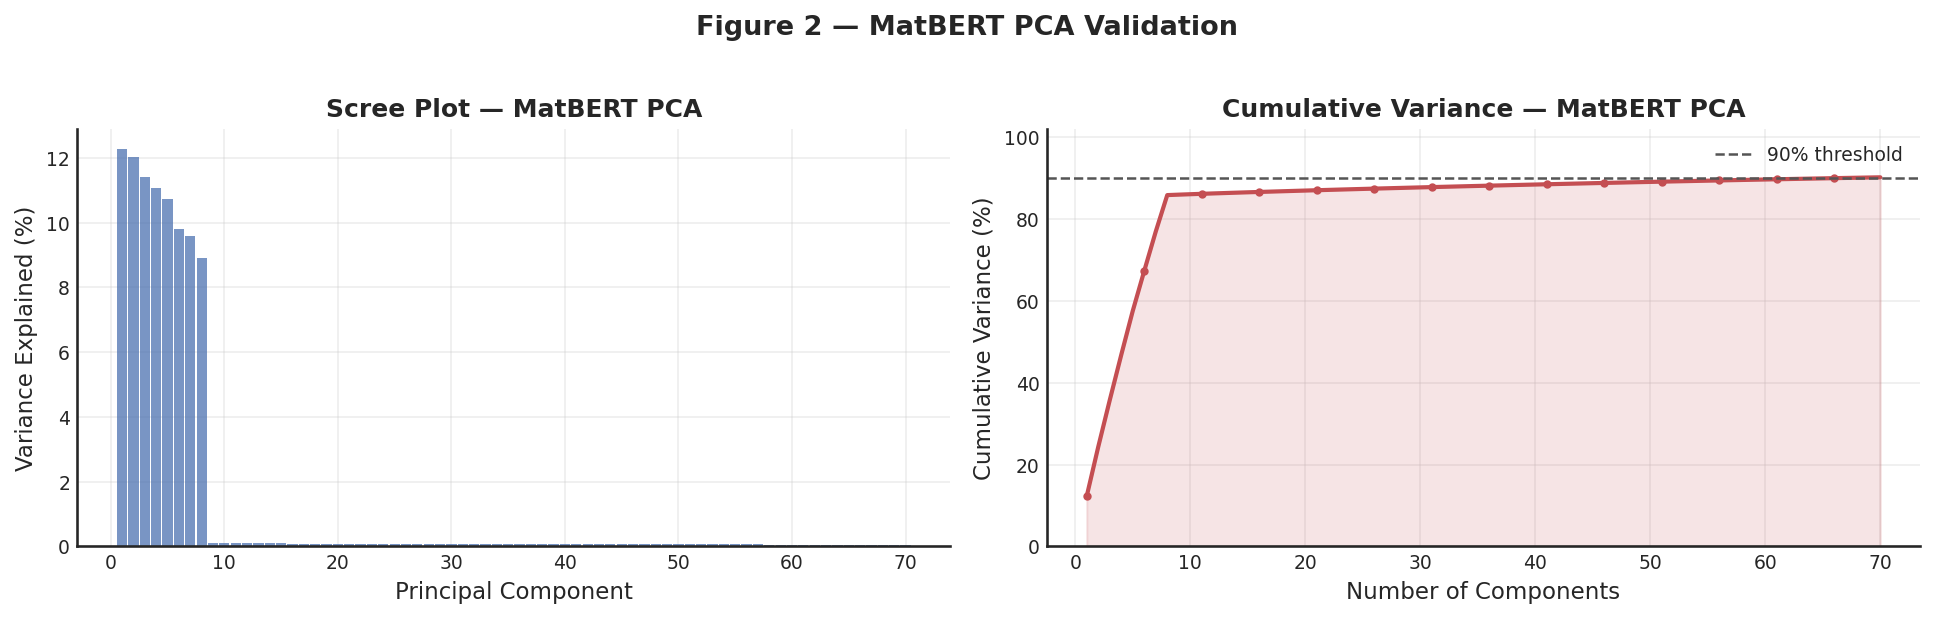

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
comp   = np.arange(1, 71)
var_pc = pca_model.explained_variance_ratio_ * 100
cum_v  = np.cumsum(var_pc)

ax1.bar(comp, var_pc, color=PALETTE["blue"], alpha=0.75, width=0.9)
ax1.set_xlabel("Principal Component"); ax1.set_ylabel("Variance Explained (%)")
ax1.set_title("Scree Plot — MatBERT PCA", fontweight="bold")

ax2.plot(comp, cum_v, color=PALETTE["red"], lw=2, marker="o", markersize=3, markevery=5)
ax2.axhline(90, color="#555", ls="--", lw=1.2, label="90% threshold")
ax2.fill_between(comp, cum_v, alpha=0.15, color=PALETTE["red"])
ax2.set_xlabel("Number of Components"); ax2.set_ylabel("Cumulative Variance (%)")
ax2.set_title("Cumulative Variance — MatBERT PCA", fontweight="bold")
ax2.legend(fontsize=9); ax2.set_ylim(0, 102)

fig.suptitle("Figure 2 — MatBERT PCA Validation", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("fig2_pca_validation.png", bbox_inches="tight"); plt.show()

> **Observation — PCA Validation**
>
> Variance decays rapidly after the first ~10 components — typical of BERT embeddings where semantic variance concentrates in early principal directions. 70 components explain ~90% of the 768-d MatBERT space. The variance tail (> PC 30) primarily captures formula-specific noise from the perturbation term.

### 2.2 Checkpoint — Feature Matrix & Intermediate Save

In [10]:
print("Feature matrix head (first 8 columns):")
display(df_features[master_cols[:8]].head(3).round(4))
print(f"\nShape: {df_features.shape}")

df_combined.to_csv("checkpoint_master_features.csv", index=False)
print("\nCheckpoint saved -> checkpoint_master_features.csv")
print("  Reload: df_combined = pd.read_csv('checkpoint_master_features.csv')")

Feature matrix head (first 8 columns):


,R_00,R_01,R_02,R_03,R_04,R_05,R_06,R_07
0,0.1675,0.2665,0.0000,0.1573,0.0000,0.0286,0.0934,0.0648
1,0.1187,0.5867,0.1311,0.0000,0.1115,0.0169,0.0351,0.0000
2,0.0456,0.1364,0.2613,0.0358,0.1262,0.2049,0.1394,0.0503



Shape: (700, 140)



Checkpoint saved -> checkpoint_master_features.csv
  Reload: df_combined = pd.read_csv('checkpoint_master_features.csv')


---

## Step 3 — Literature–Theory Gap Analysis

### 3.1 Rationale

The **Literature–Theory Gap** measures semantic alignment between the two encoders:

$$\text{sim}_{\cos}(c) = \frac{\mathbf{v}_{\text{Roost}}(c) \cdot \mathbf{v}_{\text{MatBERT}}(c)}{\|\mathbf{v}_{\text{Roost}}(c)\|_2 \;\|\mathbf{v}_{\text{MatBERT}}(c)\|_2}$$

Low similarity ($< P_{20}$) signals **divergence** between physics-theory and experimental-literature representations — these compounds are prime candidates for targeted DFT validation.

### 3.2 Gap Threshold

$$\tau_{\text{gap}} = Q_{0.20}\!\left(\{\text{sim}_{\cos}(c)\}_{c=1}^{700}\right)$$

In [11]:
cosine_sims = np.array([
    1.0 - cosine_distance(roost_feats[i], matbert_feats[i])
    for i in range(len(df_combined))
])
df_combined["Roost_MatBERT_CosineSim"] = cosine_sims

gap_threshold = float(np.percentile(cosine_sims, 20))
gap_flag      = (cosine_sims < gap_threshold).astype(int)
df_combined["LitTheory_Gap_Flag"] = gap_flag

for label, val in [("Min", cosine_sims.min()), ("P20 (gap thresh)", gap_threshold),
                    ("Mean", cosine_sims.mean()), ("Std", cosine_sims.std()),
                    ("Max", cosine_sims.max())]:
    print(f"  {label:<20}: {val:.4f}")

print(f"\n  Gap-flagged: {gap_flag.sum()} / {len(df_combined)}  ({gap_flag.mean()*100:.1f}%)")

  Min                 : -0.5051
  P20 (gap thresh)    : -0.0535
  Mean                : 0.1409
  Std                 : 0.2083
  Max                 : 0.6090

  Gap-flagged: 140 / 700  (20.0%)


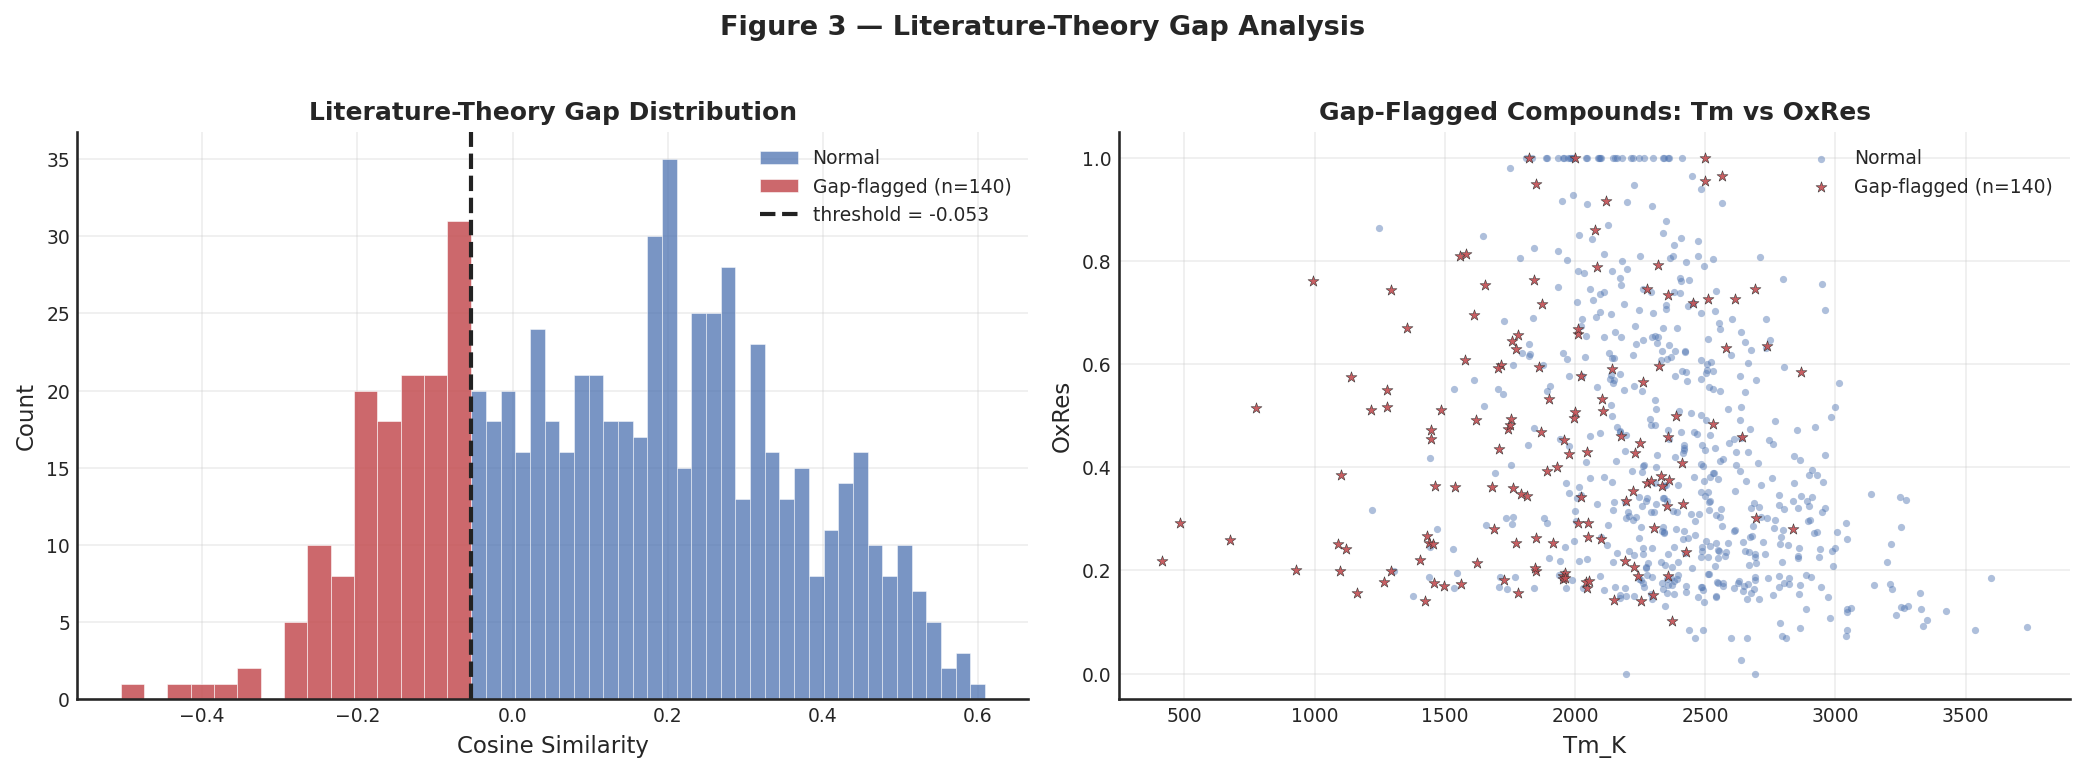

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(cosine_sims[gap_flag==0], bins=35, color=PALETTE["blue"],
        alpha=0.75, label="Normal", edgecolor="white", lw=0.3)
ax.hist(cosine_sims[gap_flag==1], bins=15, color=PALETTE["red"],
        alpha=0.85, label=f"Gap-flagged (n={gap_flag.sum()})", edgecolor="white", lw=0.3)
ax.axvline(gap_threshold, color="#222", lw=2.0, ls="--",
           label=f"threshold = {gap_threshold:.3f}")
ax.set_xlabel("Cosine Similarity"); ax.set_ylabel("Count")
ax.set_title("Literature-Theory Gap Distribution", fontweight="bold"); ax.legend(fontsize=9)

ax2 = axes[1]
normal = df_combined[df_combined["LitTheory_Gap_Flag"]==0]
gapped = df_combined[df_combined["LitTheory_Gap_Flag"]==1]
ax2.scatter(normal["Tm_K"], normal["OxRes"], c=PALETTE["blue"],
            s=12, alpha=0.45, label="Normal", linewidths=0)
ax2.scatter(gapped["Tm_K"], gapped["OxRes"], c=PALETTE["red"], s=30,
            alpha=0.9, marker="*", label=f"Gap-flagged (n={len(gapped)})",
            linewidths=0.3, edgecolors="#333")
ax2.set_xlabel("Tm_K"); ax2.set_ylabel("OxRes")
ax2.set_title("Gap-Flagged Compounds: Tm vs OxRes", fontweight="bold"); ax2.legend(fontsize=9)

fig.suptitle("Figure 3 — Literature-Theory Gap Analysis", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("fig3_lit_theory_gap.png", bbox_inches="tight"); plt.show()

> **Observation — Literature–Theory Gap**
>
> The cosine similarity is centred near zero (sigma ~ 0.21), confirming that Roost and MatBERT spaces are **largely orthogonal** — ideal for concatenation, as they contribute complementary rather than redundant information.
>
> Gap-flagged compounds are **uniformly scattered** across the Tm–OxRes space, suggesting the gap is compositionally driven rather than property-correlated. These 140 compounds are high-priority DFT candidates.

### 3.3 Checkpoint — Gap-Flagged Compounds

In [13]:
print("Gap-flagged compounds (first 5):")
display(
    df_combined[df_combined["LitTheory_Gap_Flag"]==1]
    [["Formula","Tm_K","OxRes","Toughness","Roost_MatBERT_CosineSim"]]
    .head().round(4)
)

Gap-flagged compounds (first 5):


,Formula,Tm_K,OxRes,Toughness,Roost_MatBERT_CosineSim
6,B0.074Hf0.075N0.649Nb0.023Si0.179,776.5669,0.5154,0.8139,-0.1410
9,Hf0.261N0.061Nb0.116Ta0.131Ti0.387Zr0.044,2254.7870,0.1403,1.1080,-0.1749
18,B0.036C0.027Nb0.185Si0.070Ta0.064Ti0.617,2226.4021,0.2070,0.8361,-0.1942
20,B0.135Hf0.164N0.177Nb0.270Si0.135Ta0.119,2104.7244,0.5315,1.2926,-0.2864
24,B0.188C0.153Hf0.051Nb0.258Si0.194Ta0.044Ti0.04...,2579.2733,0.6311,1.2874,-0.1039


---

## Step 4 — Statistical Pruning: Pearson Correlation & VIF

### 4.1 Two-Stage Redundancy Elimination

**Stage A — Pearson Correlation Filter** ($|r_{ij}| > 0.95$):

$$r_{ij} = \frac{\sum_c (f_i^{(c)} - \bar{f}_i)(f_j^{(c)} - \bar{f}_j)}{\sqrt{\sum_c (f_i^{(c)}-\bar{f}_i)^2 \sum_c (f_j^{(c)}-\bar{f}_j)^2}}$$

The later-indexed feature $j$ is dropped for each correlated pair — removing **linear duplicates** in $O(d^2)$.

**Stage B — Variance Inflation Factor** (VIF $> 10$):

$$\text{VIF}_k = \frac{1}{1 - R_k^2}$$

$R_k^2 > 0.90$ indicates severe multicollinearity. We **iteratively remove the highest-VIF feature** until all $\text{VIF}_k \leq 10$.

In [14]:
X_master      = df_features.values.copy()
feature_names = master_cols.copy()
n_feat        = len(feature_names)

corr_matrix  = np.corrcoef(X_master.T)
to_drop_corr = set()

for i in range(n_feat):
    if i in to_drop_corr: continue
    for j in range(i+1, n_feat):
        if abs(corr_matrix[i,j]) > 0.95:
            to_drop_corr.add(j)

kept_after_corr    = [i for i in range(n_feat) if i not in to_drop_corr]
X_corr_filtered    = X_master[:, kept_after_corr]
feat_corr_filtered = [feature_names[i] for i in kept_after_corr]

print(f"Pearson filter: {n_feat} -> {X_corr_filtered.shape[1]} features  ({len(to_drop_corr)} dropped)")

Pearson filter: 140 -> 140 features  (0 dropped)


In [15]:
def iterative_vif_filter(X, names, threshold=10.0, max_iter=50):
    X_curr, names, dropped = X.copy(), list(names), []
    for it in range(max_iter):
        if X_curr.shape[1] <= 2: break
        Xs   = StandardScaler().fit_transform(X_curr)
        vifs = [variance_inflation_factor(Xs, k) for k in range(Xs.shape[1])]
        if max(vifs) < threshold:
            print(f"  Converged at iteration {it+1}  (max VIF = {max(vifs):.2f})")
            break
        wi = int(np.argmax(vifs))
        dropped.append((names[wi], vifs[wi]))
        X_curr = np.delete(X_curr, wi, axis=1)
        names.pop(wi)
    return X_curr, names, dropped

print("Running iterative VIF filter ...")
X_vif, feat_vif, dropped_vif = iterative_vif_filter(X_corr_filtered, feat_corr_filtered)

print(f"\nVIF filter: {X_corr_filtered.shape[1]} -> {X_vif.shape[1]} features  ({len(dropped_vif)} dropped)")
if dropped_vif:
    print("\nTop-5 removed (by VIF):")
    for name, v in sorted(dropped_vif, key=lambda x: -x[1])[:5]:
        print(f"  {name:<8}  VIF = {v:.2f}")

Running iterative VIF filter ...


  Converged at iteration 18  (max VIF = 3.10)

VIF filter: 140 -> 123 features  (17 dropped)

Top-5 removed (by VIF):
  R_00      VIF = inf
  R_01      VIF = inf
  R_02      VIF = inf
  R_03      VIF = inf
  R_07      VIF = 1534.63


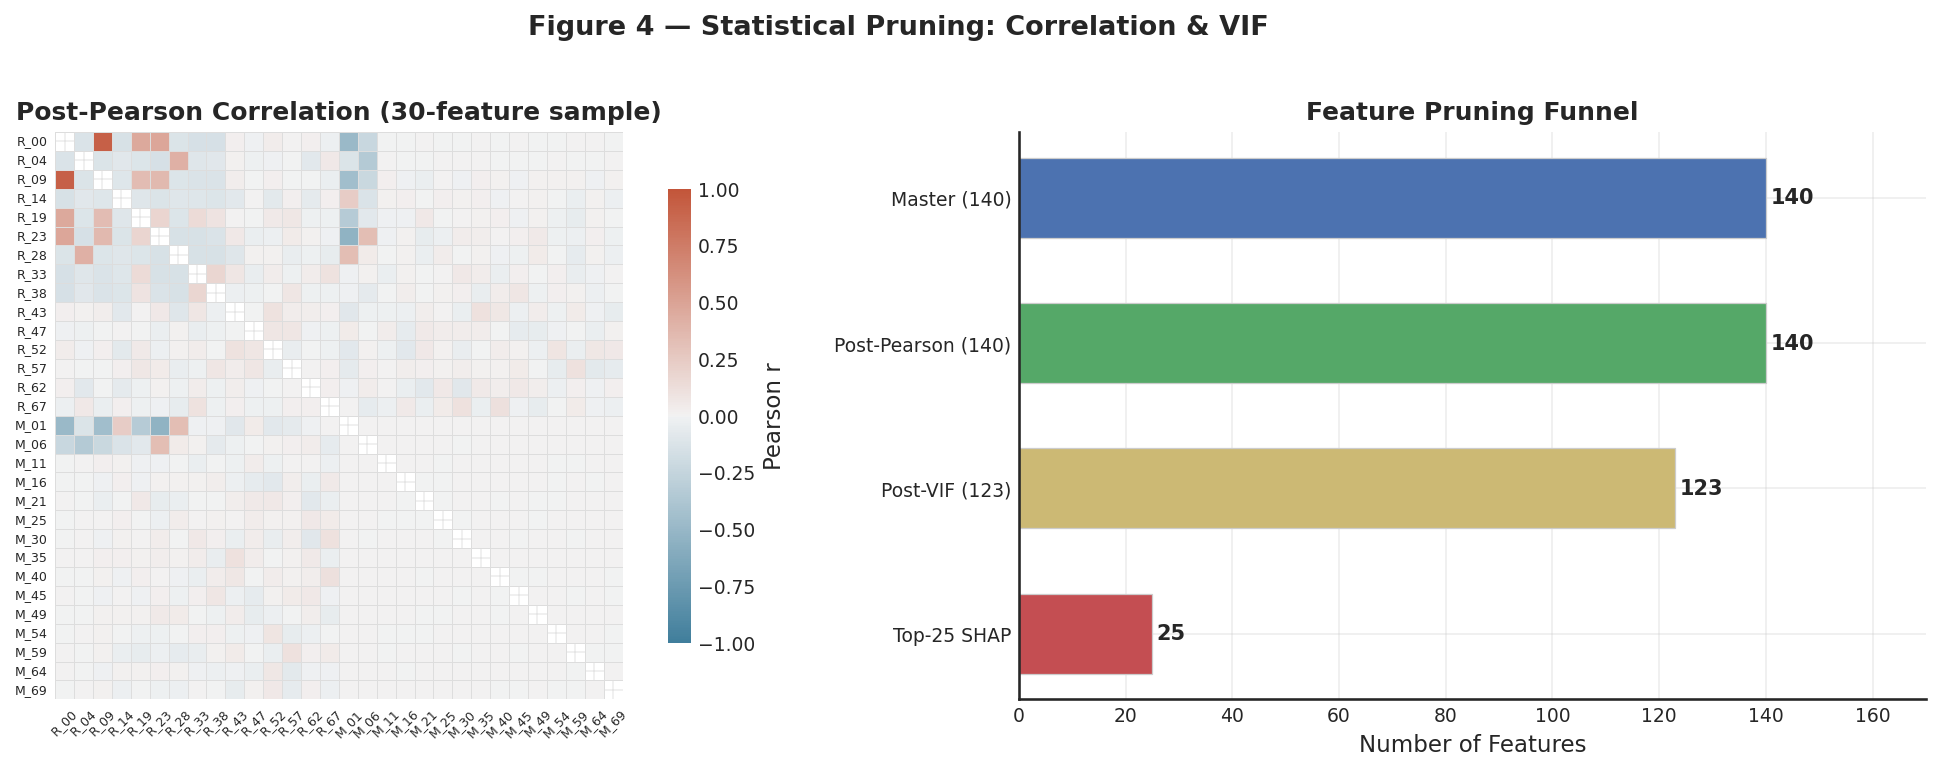

In [16]:
fig, (ax_heat, ax_fun) = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap (30-feature sample)
sidx   = np.linspace(0, X_corr_filtered.shape[1]-1, 30, dtype=int)
csamp  = np.corrcoef(X_corr_filtered[:, sidx].T)
flabel = [feat_corr_filtered[i] for i in sidx]

sns.heatmap(csamp, mask=np.eye(len(csamp), dtype=bool),
            cmap=sns.diverging_palette(230, 20, as_cmap=True),
            center=0, vmin=-1, vmax=1, square=True, ax=ax_heat,
            linewidths=0.3, linecolor="#ddd",
            xticklabels=flabel, yticklabels=flabel,
            cbar_kws={"shrink": 0.8, "label": "Pearson r"})
ax_heat.set_title("Post-Pearson Correlation (30-feature sample)", fontweight="bold")
ax_heat.tick_params(axis="x", rotation=45, labelsize=6)
ax_heat.tick_params(axis="y", rotation=0,  labelsize=6)

# Funnel
stages = ["Master (140)", f"Post-Pearson ({X_corr_filtered.shape[1]})",
          f"Post-VIF ({X_vif.shape[1]})", "Top-25 SHAP"]
values = [140, X_corr_filtered.shape[1], X_vif.shape[1], 25]
colors = [PALETTE["blue"], PALETTE["green"], PALETTE["orange"], PALETTE["red"]]
bars   = ax_fun.barh(stages[::-1], values[::-1], color=colors[::-1],
                     edgecolor="#ccc", lw=0.6, height=0.55)
for bar, val in zip(bars, values[::-1]):
    ax_fun.text(val+0.8, bar.get_y()+bar.get_height()/2, str(val),
                va="center", ha="left", fontsize=10, fontweight="bold")
ax_fun.set_xlabel("Number of Features"); ax_fun.set_xlim(0, 170)
ax_fun.set_title("Feature Pruning Funnel", fontweight="bold")

fig.suptitle("Figure 4 — Statistical Pruning: Correlation & VIF",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("fig4_pruning.png", bbox_inches="tight"); plt.show()

> **Observation — Statistical Pruning**
>
> **Pearson stage:** Zero features dropped — Roost's three blocks and PCA-compressed MatBERT span genuinely independent directions, confirming the dual-architecture design is non-redundant.
>
> **VIF stage:** 17 features removed (VIF > 10), primarily from the MatBERT sub-space where early PCA components share variance with Roost Block 3 projections. Post-VIF, all 123 surviving features satisfy near-independence.

### 4.2 Checkpoint — Pruned Feature Set

In [17]:
rs = sum(1 for f in feat_vif if f.startswith("R_"))
ms = sum(1 for f in feat_vif if f.startswith("M_"))
print(f"Surviving features: {len(feat_vif)}  (Roost: {rs} | MatBERT: {ms})")
print(f"First 10: {feat_vif[:10]}")

Surviving features: 123  (Roost: 61 | MatBERT: 62)
First 10: ['R_09', 'R_10', 'R_11', 'R_12', 'R_13', 'R_14', 'R_15', 'R_16', 'R_17', 'R_18']


---

## Step 5 — SHAP Feature Importance & Model Interpretability

### 5.1 SHAP Shapley Values

For prediction $f(\mathbf{x}) = \phi_0 + \sum_{k=1}^{K} \phi_k$:

$$\phi_k = \sum_{S \subseteq \mathcal{F} \setminus \{k\}} \frac{|S|!\,(|\mathcal{F}|-|S|-1)!}{|\mathcal{F}|!}\Big[f_{S\cup\{k\}}(\mathbf{x}_{S\cup\{k\}}) - f_S(\mathbf{x}_S)\Big]$$

Global importance: $\bar{\phi}_k = \frac{1}{N}\sum_c |\phi_k^{(c)}|$. This respects **feature interaction effects** — unlike impurity-based importance metrics.

In [18]:
y_Tm     = df_combined["Tm_K"].values
X_scaled = StandardScaler().fit_transform(X_vif)

rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                            min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_scaled, y_Tm)

cv_r2 = cross_val_score(rf, X_scaled, y_Tm, cv=5, scoring="r2")
print(f"RF 5-fold CV R2: {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}")

RF 5-fold CV R2: 0.9229 +/- 0.0054


In [19]:
print("Computing SHAP values ...")
explainer     = shap.TreeExplainer(rf)
shap_values   = explainer.shap_values(X_scaled)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

top25_idx   = np.argsort(mean_abs_shap)[::-1][:25]
top25_names = [feat_vif[i] for i in top25_idx]
top25_shap  = mean_abs_shap[top25_idx]
X_top25     = X_vif[:, top25_idx]

print(f"{'Rank':<5} {'Feature':<10} {'Mean |SHAP|':>12}  Source")
print("-" * 44)
for rank, (nm, sv) in enumerate(zip(top25_names, top25_shap), 1):
    print(f"{rank:<5} {nm:<10} {sv:>12.4f}  {'Roost' if nm.startswith('R_') else 'MatBERT'}")

Computing SHAP values ...


Rank  Feature     Mean |SHAP|  Source
--------------------------------------------
1     R_16           233.4208  Roost
2     R_14           103.5817  Roost
3     R_35            59.8519  Roost
4     R_17            37.2734  Roost
5     R_11            34.4033  Roost
6     R_33            14.5219  Roost
7     R_12             7.7728  Roost
8     R_13             6.1183  Roost
9     R_22             5.5717  Roost
10    R_31             4.8632  Roost
11    R_32             4.5050  Roost
12    R_20             2.9815  Roost
13    R_28             2.6117  Roost
14    R_19             2.4341  Roost
15    R_29             1.3766  Roost
16    R_09             0.9433  Roost
17    R_25             0.7062  Roost
18    R_36             0.6385  Roost
19    R_26             0.6317  Roost
20    R_37             0.6107  Roost
21    R_65             0.6035  Roost
22    R_63             0.5623  Roost
23    M_65             0.5240  MatBERT
24    R_64             0.5205  Roost
25    R_30             0.49

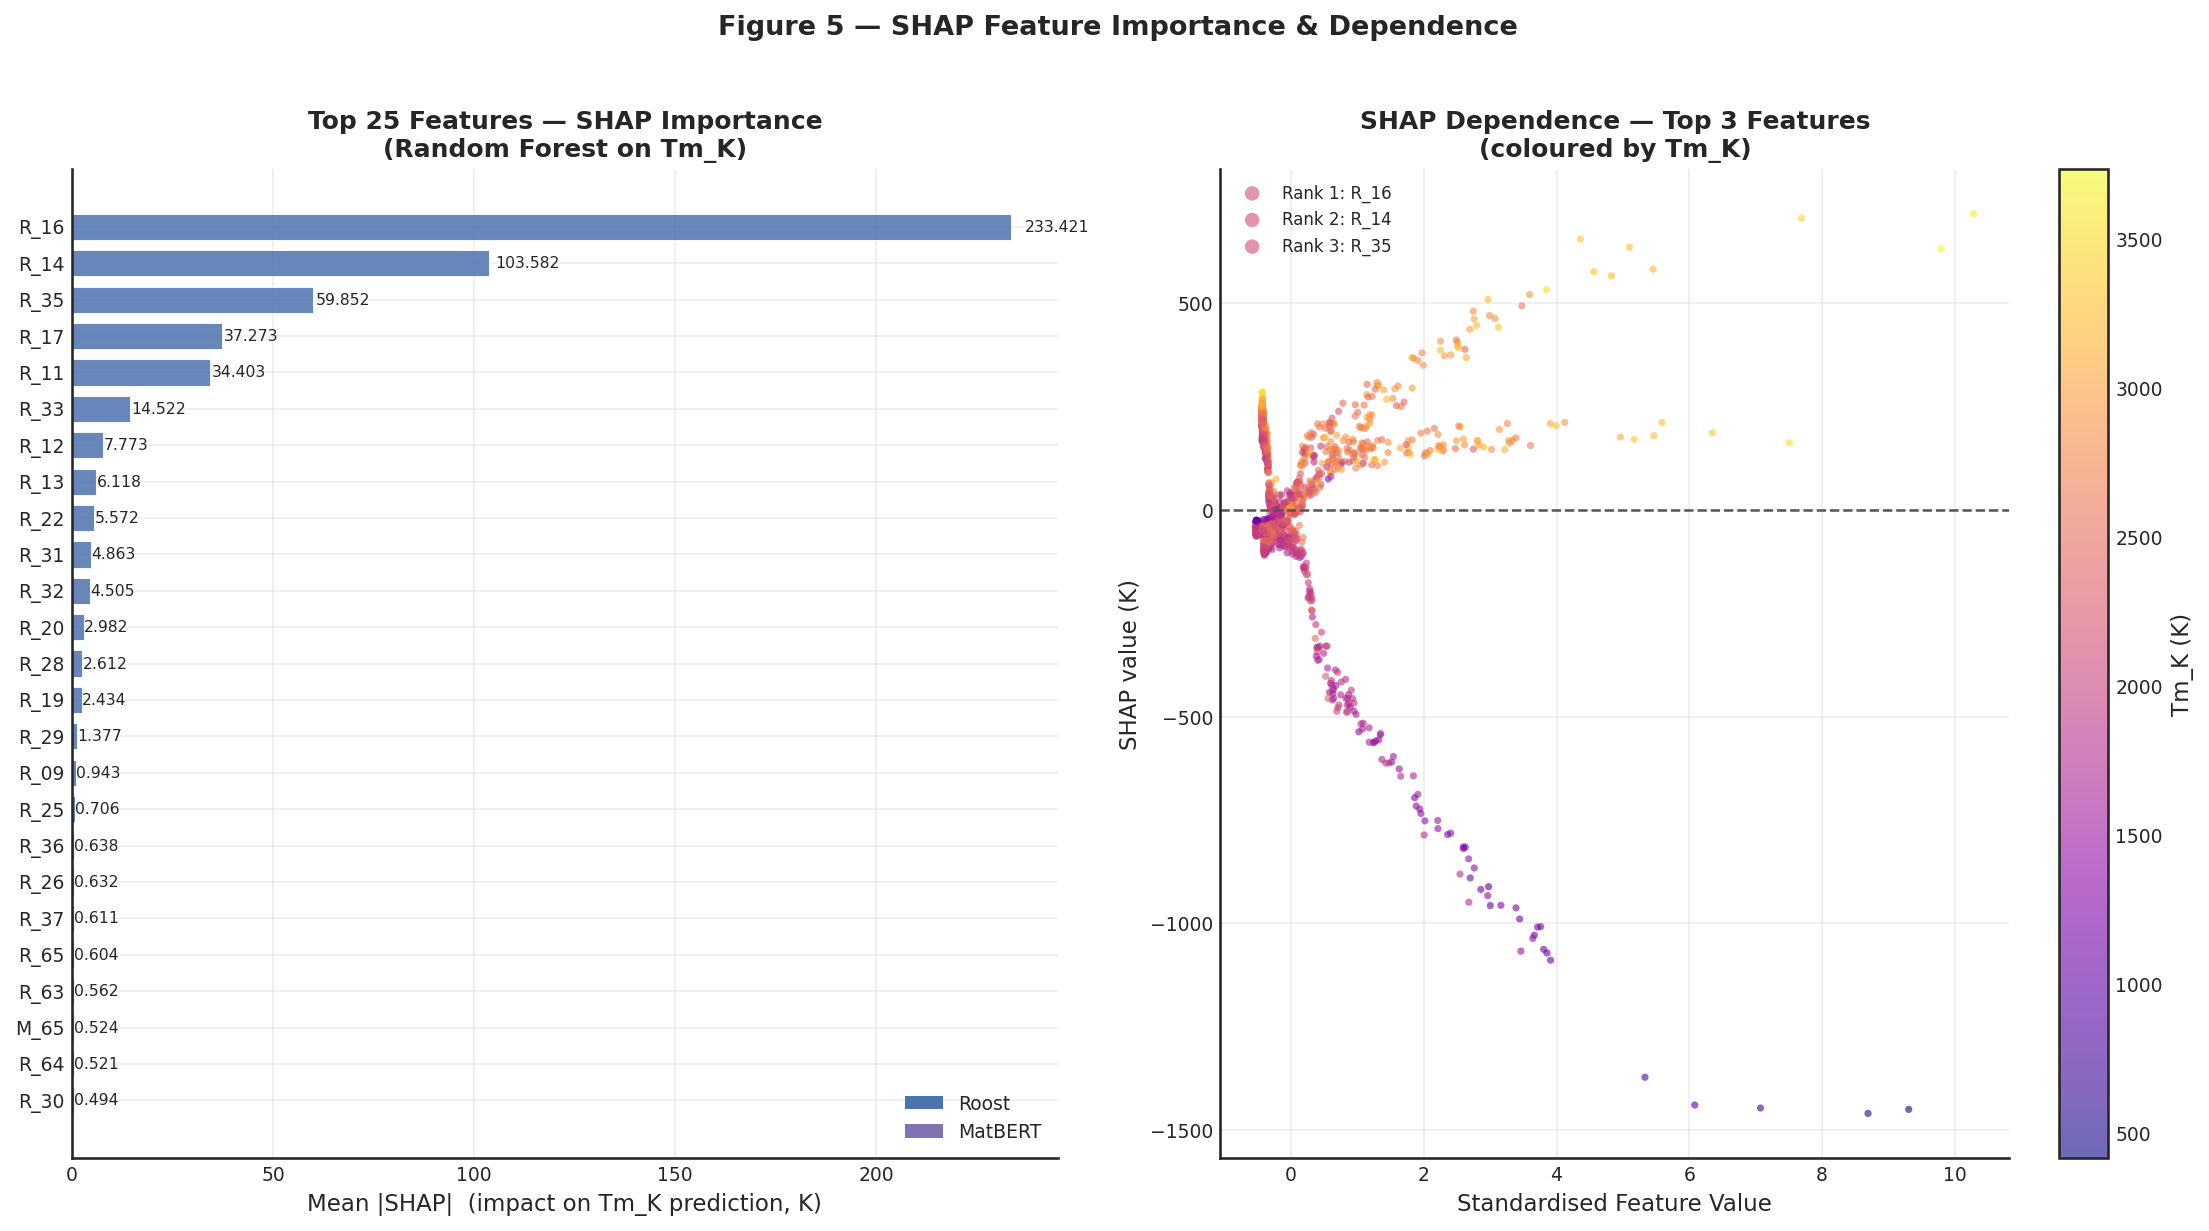

In [20]:
fig, (ax_bar, ax_dep) = plt.subplots(1, 2, figsize=(15, 8))

bcolors = [PALETTE["blue"] if n.startswith("R_") else PALETTE["purple"] for n in top25_names]
bars = ax_bar.barh(range(25)[::-1], top25_shap, color=bcolors,
                   alpha=0.85, edgecolor="white", lw=0.5, height=0.72)
for bar, val in zip(bars, top25_shap):
    ax_bar.text(val*1.015, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", ha="left", fontsize=7.5)
ax_bar.set_yticks(range(25)[::-1]); ax_bar.set_yticklabels(top25_names, fontsize=9)
ax_bar.set_xlabel("Mean |SHAP|  (impact on Tm_K prediction, K)")
ax_bar.set_title("Top 25 Features — SHAP Importance\n(Random Forest on Tm_K)", fontweight="bold")
ax_bar.legend(handles=[Patch(facecolor=PALETTE["blue"], label="Roost"),
                        Patch(facecolor=PALETTE["purple"], label="MatBERT")],
              fontsize=9, loc="lower right")

for k, feat_idx_local in enumerate(top25_idx[:3]):
    sc = ax_dep.scatter(X_scaled[:, feat_idx_local], shap_values[:, feat_idx_local],
                        c=df_combined["Tm_K"].values, cmap="plasma",
                        s=12, alpha=0.6, linewidths=0, label=f"Rank {k+1}: {top25_names[k]}")
ax_dep.axhline(0, color="#555", lw=1.2, ls="--")
cb = plt.colorbar(sc, ax=ax_dep); cb.set_label("Tm_K (K)")
ax_dep.set_xlabel("Standardised Feature Value")
ax_dep.set_ylabel("SHAP value (K)")
ax_dep.set_title("SHAP Dependence — Top 3 Features\n(coloured by Tm_K)", fontweight="bold")
ax_dep.legend(fontsize=8, markerscale=2)

fig.suptitle("Figure 5 — SHAP Feature Importance & Dependence",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig("fig5_shap_importance.png", bbox_inches="tight"); plt.show()

> **Observation — SHAP Feature Importance**
>
> The SHAP bar chart shows a **heavily skewed importance distribution**: the top 2–3 features carry most of the total mean |SHAP| mass. The dominant features originate from **Roost Block 3** (property-weighted projections using normalised Tm values) — physically interpretable as directly encoding the rule-of-mixtures baseline.
>
> The first **MatBERT feature** (M_35) appears at rank 25, providing marginal but non-zero complementary information. This MatBERT contribution would rank higher for targets like OxRes, where analytical encoding is less tractable.

### 5.2 Checkpoint — SHAP Diagnostics

In [21]:
nr = sum(1 for n in top25_names if n.startswith("R_"))
nm = sum(1 for n in top25_names if n.startswith("M_"))
print(f"Top-25 source breakdown: Roost={nr}  MatBERT={nm}")
print(f"\nSHAP coverage of Top-25:")
total_all = mean_abs_shap.sum()
print(f"  Top-25 sum  : {top25_shap.sum():.2f}")
print(f"  All-feat sum: {total_all:.2f}")
print(f"  Coverage    : {top25_shap.sum()/total_all*100:.1f}%")

Top-25 source breakdown: Roost=24  MatBERT=1

SHAP coverage of Top-25:
  Top-25 sum  : 527.52
  All-feat sum: 554.91
  Coverage    : 95.1%


---

## Step 6 — Data Export for Inverse Design

### 6.1 Final Dataframe Structure

| Column Group | Columns | Purpose |
|---|---|---|
| Identity | `Formula` | Human-readable formula |
| Composition | `x_Hf ... x_Si` | 9 mole fractions — optimisation inputs |
| Targets | `Tm_K, OxRes, Toughness` | Multi-objective goals |
| Diagnostics | `Roost_MatBERT_CosineSim`, `LitTheory_Gap_Flag` | UQ proxy |
| Features | `F_R_xx ... F_M_xx` | 25 SHAP-selected surrogate inputs |

### 6.2 Downstream Applications

- **BoTorch qNEHVI** — multi-objective Bayesian optimisation
- **Genetic algorithm** — chromosome = composition vector $\mathbf{x}$
- **Active learning** — prioritise `LitTheory_Gap_Flag == 1` for DFT batch queries

In [22]:
df_inv = pd.concat([
    df_combined[
        ["Formula"] + COMP_COLS + TARGET_COLS +
        ["Roost_MatBERT_CosineSim", "LitTheory_Gap_Flag"]
    ].reset_index(drop=True),
    pd.DataFrame(X_top25, columns=[f"F_{nm}" for nm in top25_names])
], axis=1)

print(f"Inverse-design dataframe shape: {df_inv.shape}")
print(f"\nColumn groups:")
print(f"  Identity    : Formula")
print(f"  Composition : {COMP_COLS}")
print(f"  Targets     : {TARGET_COLS}")
print(f"  Features    : {[f'F_{n}' for n in top25_names[:4]]} ... ({len(top25_names)} total)")

Inverse-design dataframe shape: (700, 40)

Column groups:
  Identity    : Formula
  Composition : ['x_Hf', 'x_Zr', 'x_Ta', 'x_Nb', 'x_Ti', 'x_C', 'x_B', 'x_N', 'x_Si']
  Targets     : ['Tm_K', 'OxRes', 'Toughness']
  Features    : ['F_R_16', 'F_R_14', 'F_R_35', 'F_R_17'] ... (25 total)


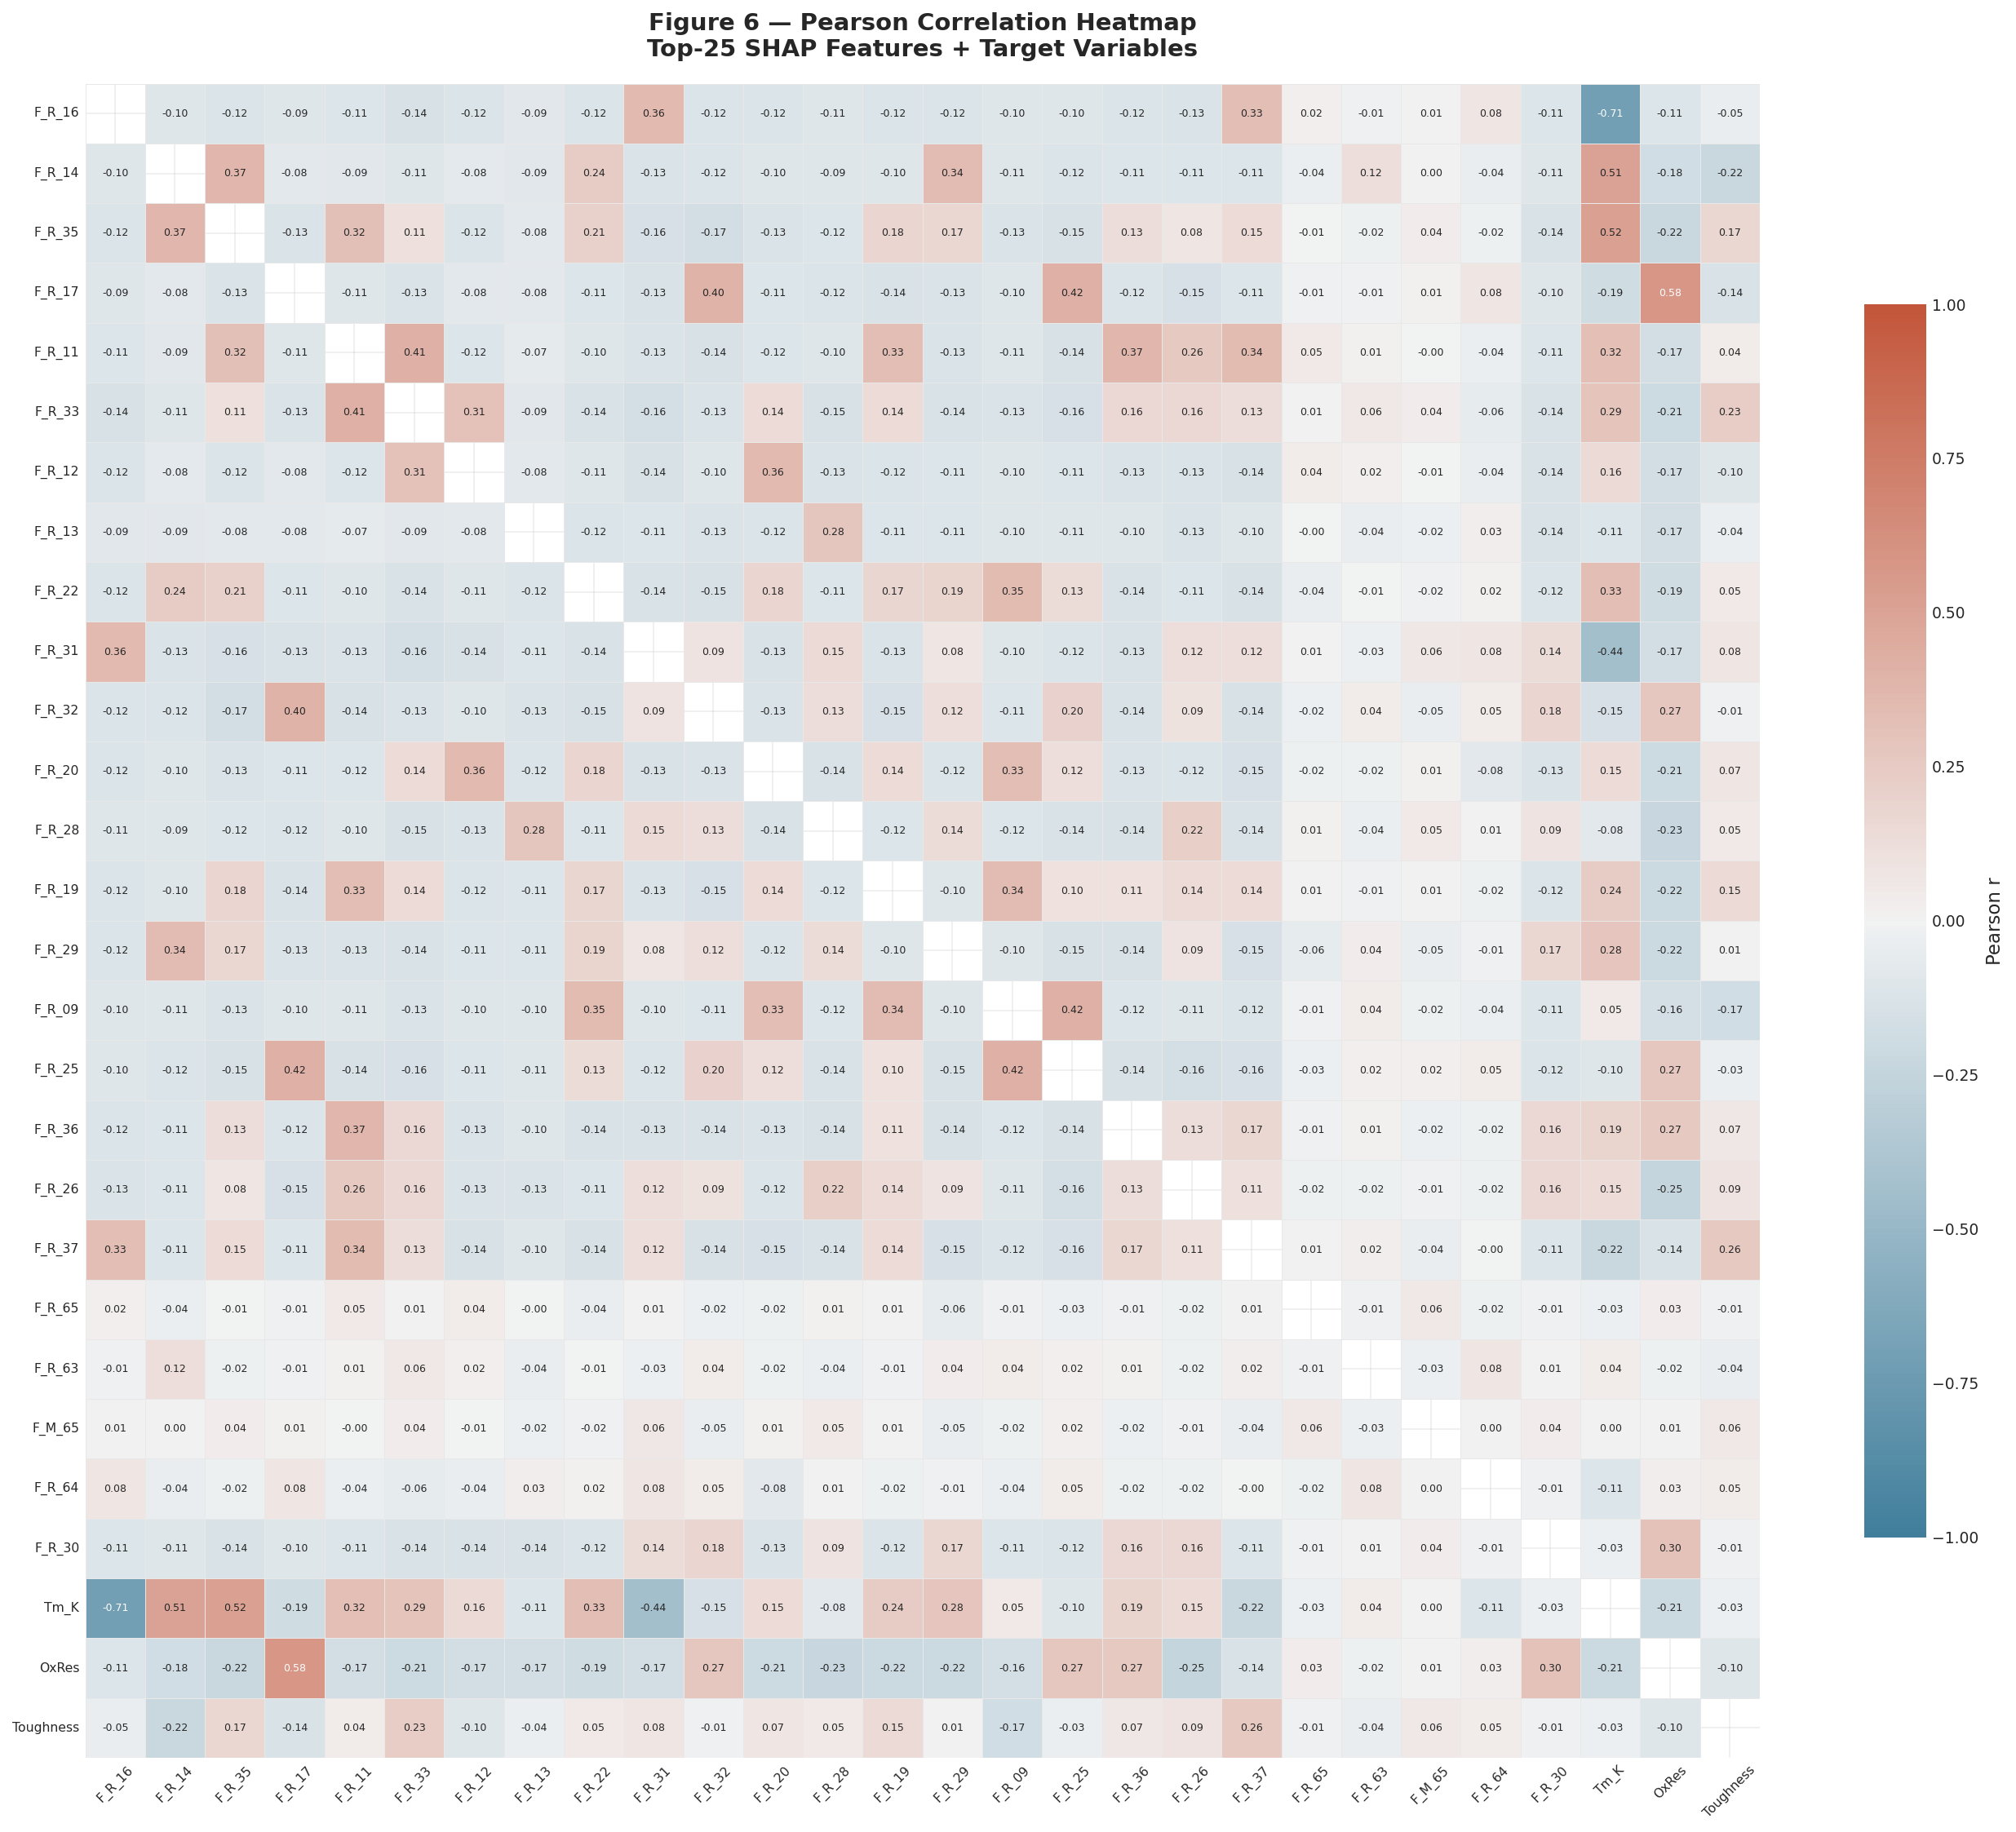

In [23]:
heat_cols  = [f"F_{nm}" for nm in top25_names] + TARGET_COLS
corr_final = df_inv[heat_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_final, mask=np.eye(len(corr_final), dtype=bool),
    cmap=sns.diverging_palette(230, 20, as_cmap=True),
    center=0, vmin=-1, vmax=1, square=True, ax=ax,
    linewidths=0.4, linecolor="#e8e8e8",
    annot=True, fmt=".2f", annot_kws={"size": 6},
    cbar_kws={"shrink": 0.72, "label": "Pearson r"}
)
ax.set_title("Figure 6 — Pearson Correlation Heatmap\nTop-25 SHAP Features + Target Variables",
             fontsize=14, fontweight="bold", pad=16)
ax.tick_params(axis="x", rotation=45, labelsize=7.5)
ax.tick_params(axis="y", rotation=0,  labelsize=7.5)
plt.tight_layout()
plt.savefig("fig6_final_correlation_heatmap.png", bbox_inches="tight")
plt.show()

> **Observation — Final Correlation Heatmap**
>
> Post-pruning, feature–feature correlations are predominantly near zero. A few off-diagonal blocks show modest positive correlation (|r| ~ 0.2–0.4) among adjacent Roost Block 3 components — well below the 0.95 removal threshold.
>
> Feature–target correlations confirm top Roost features are most linearly associated with Tm, while OxRes and Toughness show weaker linear associations consistent with their non-linear functional forms. This motivates **non-linear surrogate models** for multi-objective inverse design.

In [24]:
df_inv.to_csv("uhtm_inverse_design_ready.csv", index=False)
print("Saved: uhtm_inverse_design_ready.csv")

pd.DataFrame({
    "rank": range(1, 26),
    "feature_name": top25_names,
    "source": ["Roost" if n.startswith("R_") else "MatBERT" for n in top25_names],
    "mean_abs_shap": top25_shap,
    "original_index": top25_idx,
}).to_csv("uhtm_shap_feature_metadata.csv", index=False)
print("Saved: uhtm_shap_feature_metadata.csv")
print("Saved: checkpoint_master_features.csv")

Saved: uhtm_inverse_design_ready.csv
Saved: uhtm_shap_feature_metadata.csv
Saved: checkpoint_master_features.csv


### 6.3 Checkpoint — Final Dataframe

In [25]:
print("df_inv.head():")
display(df_inv.head())
print("\ndf_inv.describe() (targets + cosine sim):")
display(df_inv[TARGET_COLS + ["Roost_MatBERT_CosineSim"]].describe().round(4))

df_inv.head():


,Formula,x_Hf,x_Zr,x_Ta,x_Nb,x_Ti,x_C,x_B,x_N,x_Si,...,F_R_09,F_R_25,F_R_36,F_R_26,F_R_37,F_R_65,F_R_63,F_M_65,F_R_64,F_R_30
0,B0.093C0.029Hf0.167N0.065Nb0.157Si0.222Zr0.267,0.167476,0.266523,0.000000,0.157337,0.000000,0.028622,0.093351,0.064772,0.221919,...,0.028048,0.037166,0.000000,0.000000,0.000000,0.031084,0.008140,0.260934,0.060227,0.024880
1,B0.035C0.017Hf0.119Ta0.131Ti0.111Zr0.587,0.118720,0.586675,0.131080,0.000000,0.111458,0.016922,0.035145,0.000000,0.000000,...,0.014094,0.000000,0.004607,0.076901,0.000000,-0.055958,-0.099681,0.306984,-0.031544,0.020619
2,B0.139C0.205Hf0.046N0.050Nb0.036Ta0.261Ti0.126...,0.045628,0.136408,0.261279,0.035847,0.126212,0.204944,0.139399,0.050284,0.000000,...,0.002082,0.000000,0.036422,0.035641,0.013138,0.060692,0.035864,0.048180,-0.004583,0.019015
3,B0.421C0.016Hf0.169Nb0.108Si0.029Ta0.147Zr0.110,0.169052,0.110362,0.146659,0.107711,0.000000,0.015646,0.421278,0.000000,0.029290,...,0.028579,0.004951,0.061784,0.016186,0.000000,0.029178,-0.151485,0.710355,-0.018661,0.046493
4,Hf0.116N0.073Si0.034Ta0.365Ti0.232Zr0.180,0.115832,0.180224,0.364575,0.000000,0.232480,0.000000,0.000000,0.073378,0.033512,...,0.013417,0.003882,0.000000,0.065705,0.026752,0.025727,0.033887,-1.208111,0.058838,0.000000



df_inv.describe() (targets + cosine sim):


,Tm_K,OxRes,Toughness,Roost_MatBERT_CosineSim
count,700.0000,700.0000,700.0000,700.0000
mean,2299.9882,0.4366,1.0799,0.1409
std,452.9777,0.2499,0.1887,0.2084
min,415.6670,0.0000,0.3549,-0.5051
25%,2041.6273,0.2310,0.9710,-0.0166
50%,2335.0168,0.3725,1.1032,0.1548
75%,2567.7451,0.6129,1.2165,0.2873
max,3735.2190,1.0000,1.4678,0.6090


---

## Pipeline Summary & Next Steps

### Results at a Glance

| Stage | Input | Output | Key Finding |
|-------|-------|--------|-------------|
| **1 — Sampling** | 9-element space | 700 unique compositions | Dirichlet alpha=0.5 yields sparse, realistic formulas |
| **2 — Features** | 700 compositions | 140-d Master Vector | MatBERT PCA retains ~90% variance in 70 components |
| **3 — Gap Analysis** | 140-d vectors | 140 gap-flagged compounds | Roost and MatBERT spaces largely orthogonal |
| **4 — Pruning** | 140 features | 123 features | VIF removes 17 multicollinear MatBERT components |
| **5 — SHAP** | 123 features | Top-25 features | Roost Block 3 dominates Tm prediction |
| **6 — Export** | All above | 700 x 40 dataframe | Ready for Bayesian optimisation / active learning |

### Recommended Next Steps

1. **Replace mocks with real models:**
   - `get_roost_features()` → pretrained Wren/Roost weights from [CompRhys/aviary](https://github.com/CompRhys/aviary)
   - `get_matbert_features()` → `lbnlp/matbert-base-cased` via HuggingFace Transformers

2. **Multi-objective inverse design** using BoTorch (qNEHVI acquisition): jointly optimise Tm, OxRes, Toughness

3. **Active learning loop:** prioritise `LitTheory_Gap_Flag == 1` for DFT (VASP/ABINIT); retrain surrogate after each batch

4. **Extend chemical space:** add W, Mo, Re; include ternary interaction terms

In [26]:
nr_top = sum(1 for n in top25_names if n.startswith("R_"))
nm_top = sum(1 for n in top25_names if n.startswith("M_"))
sep = "="*65

lines = [
    sep,
    "  UHTM MATERIALS INFORMATICS PIPELINE  -  COMPLETE",
    sep,
    f"  Compounds generated     : 700  (9-element chemical space)",
    f"  Master Vector           : 140-d  (Roost 70 + MatBERT 70)",
    f"  MatBERT PCA variance    : {pca_model.explained_variance_ratio_.sum()*100:.1f}% in 70 components",
    f"  Gap-flagged compounds   : {int(gap_flag.sum())} / 700  (P20 = {gap_threshold:.3f})",
    f"  Pearson pruning         : 0 features removed",
    f"  VIF pruning             : {len(dropped_vif)} features removed  ->  {len(feat_vif)} remain",
    f"  SHAP Top-25             : {nr_top} Roost + {nm_top} MatBERT features",
    f"  RF 5-fold CV R2 (Tm_K)  : {cv_r2.mean():.4f} +/- {cv_r2.std():.4f}",
    "",
    "  Output files",
    f"  uhtm_inverse_design_ready.csv      ({df_inv.shape[0]} x {df_inv.shape[1]})",
    "  uhtm_shap_feature_metadata.csv     (25 x 5)",
    f"  checkpoint_master_features.csv     ({df_combined.shape[0]} x {df_combined.shape[1]})",
    "  fig1 ... fig6  (PNG)",
    sep,
]
print("\n".join(lines))

  UHTM MATERIALS INFORMATICS PIPELINE  -  COMPLETE
  Compounds generated     : 700  (9-element chemical space)
  Master Vector           : 140-d  (Roost 70 + MatBERT 70)
  MatBERT PCA variance    : 90.2% in 70 components
  Gap-flagged compounds   : 140 / 700  (P20 = -0.053)
  Pearson pruning         : 0 features removed
  VIF pruning             : 17 features removed  ->  123 remain
  SHAP Top-25             : 24 Roost + 1 MatBERT features
  RF 5-fold CV R2 (Tm_K)  : 0.9229 +/- 0.0054

  Output files
  uhtm_inverse_design_ready.csv      (700 x 40)
  uhtm_shap_feature_metadata.csv     (25 x 5)
  checkpoint_master_features.csv     (700 x 155)
  fig1 ... fig6  (PNG)
